In [4]:
import pydicom as dicom
import matplotlib.pylab as plt
import os

def get_dcm_directory(patient_ID, patient_dict):
    
    patient_dir = dicom_dir + patient_ID + "/"
    dcm_imgs    = []
    
    for _ in range(len(patient_dict[patient_ID])):
        
        curr_dir = patient_dir + patient_dict[patient_ID][_]
        
        if curr_dir[-3:]=="dcm":
    
            dcm_imgs.append(dicom.dcmread(curr_dir))
    
    return dcm_imgs

In [7]:
dicom_dir    = "data/"
patient_dict = dict.fromkeys(os.listdir(dicom_dir))
 

for key in patient_dict.keys():
    
    patient_dir       = dicom_dir + key + "/"
    patient_dict[key] = os.listdir(patient_dir)

In [8]:
patient_imgs          = get_dcm_directory(patient_ID='6026263_20201_2_0', patient_dict=patient_dict) 

(-0.5, 223.5, 173.5, -0.5)

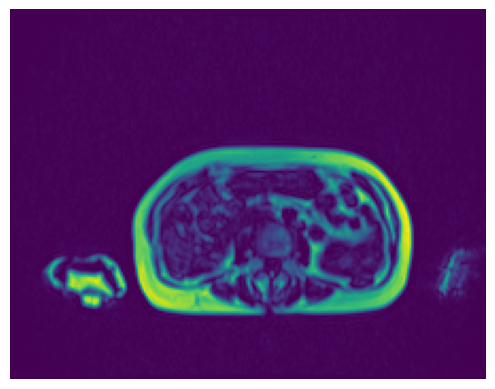

In [9]:
plt.imshow(patient_imgs[8].pixel_array)
plt.axis('off')

In [ ]:
patient_imgs[8]

In [2]:
import numpy as np
import dicom
import os
import matplotlib.pyplot as plt
from glob import glob
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import scipy.ndimage
from skimage import morphology
from skimage import measure
from skimage.transform import resize
from sklearn.cluster import KMeans
from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from plotly.tools import FigureFactory as FF
from plotly.graph_objs import *

In [20]:
def load_scan(path):
    
    slices              = [dicom.read_file(path + '/' + s, force=True) for s in os.listdir(path) if s[-3:]=="dcm"]
    slices.sort(key = lambda x: int(x.InstanceNumber))
    
    try:
        slice_thickness = np.abs(slices[0].ImagePositionPatient[2] - slices[1].ImagePositionPatient[2])
    except:
        slice_thickness = np.abs(slices[0].SliceLocation - slices[1].SliceLocation)
        
    for s in slices:
        s.SliceThickness = slice_thickness
        
    return slices

def get_pixels_hu(scans):
    image = np.stack([s.pixel_array for s in scans])
    # Convert to int16 (from sometimes int16), 
    # should be possible as values should always be low enough (<32k)
    image = image.astype(np.int16)

    # Set outside-of-scan pixels to 1
    # The intercept is usually -1024, so air is approximately 0
    image[image == -2000] = 0
    
    # Convert to Hounsfield units (HU)
    intercept = scans[0].RescaleIntercept
    slope = scans[0].RescaleSlope
    
    if slope != 1:
        image = slope * image.astype(np.float64)
        image = image.astype(np.int16)
        
    image += np.int16(intercept)
    
    return np.array(image, dtype=np.int16)

In [ ]:
data_path = 'data/6026263_20201_2_0'
slices    = load_scan(data_path)
imgs      = get_pixels_hu(slices)

In [31]:
slices[100]

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 216
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.2.18.141243.2019070914344372825277502
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002, 0013) Implementation Version Name         SH: 'OFFIS_DCMBP_360'
(0002, 0016) Source Application Entity Title     AE: 'AWP141243'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'DIS2D']
(0008, 0012) Instance Creation Date              DA: '20190709'
(0008, 0013) Instance Creation Time              TM: '143448.607000'
(0008, 0016) SO

In [32]:
!git clone https://github.com/BioMedIA/UKBB-GNC-Abdominal-Segmentation.git

Cloning into 'UKBB-GNC-Abdominal-Segmentation'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 18 (delta 7), reused 1 (delta 0), pack-reused 0
Unpacking objects: 100% (18/18), done.


In [1]:
!python extract_ukbb.py --zip_folder data/ --nifti_folder nifti/ --num_subjects 1

2022-12-18 03:33:25,304: Started extract_ukbb...
2022-12-18 03:33:25,304: zip_folder: /home/jupyter/MRI-spleen/data
2022-12-18 03:33:25,304: nifti_folder: /home/jupyter/MRI-spleen/nifti
2022-12-18 03:33:25,305: num_subjects: 1
2022-12-18 03:33:25,305: start_idx: 0

2022-12-18 03:33:25,305: Number of subjects will be converted: 1

2022-12-18 03:33:25,305: Stitching tool: /home/jupyter/MRI-spleen/stitching

2022-12-18 03:33:25,305: Currently converting subject id [6026263]: /home/jupyter/MRI-spleen/nifti/6026263/
/home/jupyter/MRI-spleen/stitching: error while loading shared libraries: libboost_program_options.so.1.65.1: cannot open shared object file: No such file or directory
2022-12-18 03:33:36,082: Output [T1_in.nii.gz]: b''
2022-12-18 03:33:36,083: Error [T1_in.nii.gz]: None
/home/jupyter/MRI-spleen/stitching: error while loading shared libraries: libboost_program_options.so.1.65.1: cannot open shared object file: No such file or directory
2022-12-18 03:33:36,090: Output [T1_opp.nii

In [1]:
import SimpleITK as sitk
import numpy as np

# A path to a T1-weighted brain .nii image:
t1_fn   = 'nifti/6026263/fat.nii.gz'

# Read the .nii image containing the volume with SimpleITK:
sitk_t1 = sitk.ReadImage(t1_fn)

# and access the numpy array:
t1     = sitk.GetArrayFromImage(sitk_t1)

In [2]:
t1.shape

(363, 168, 224)

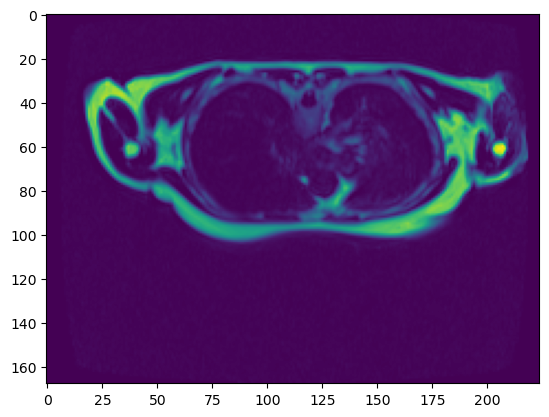

In [10]:
plt.imshow(t1[300, :, :])

In [ ]:
# TO DO: - Understand the nifti o/ps of the extractor script
#        - torchio data loaders
#        - UNet3D conversion